<a href="https://colab.research.google.com/github/prajjaldhar/DataScience/blob/main/AI_Hindi_Song_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  AI-Powered Hindi Song Recommendation System

A Data Science project using **Pandas, EDA, feature engineering, TF-IDF, cosine similarity and K-Means**.

**Dataset:** 200 Hindi/Bollywood songs spanning 2000–2026.

> `sentiment_label` and `mood` are project annotations created for recommendation experiments; they are not official music-industry labels.

## Project Pipeline
```text
CSV → Cleaning → EDA → Feature Engineering → TF-IDF → Cosine Similarity
                                                ↓
                              Mood/Sentiment Re-ranking → Top-N Recommendations
                                                ↓
                                           K-Means Clusters
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib
pd.set_option('display.max_colwidth', 100)

In [2]:
df = pd.read_csv('hindi_songs_2000_2026_200.csv')
df.head()

,song_id,song_name,singer_name,song_type,sentiment_label,mood,year,movie_name,actors
0,HS001,Dil Ne Yeh Kaha Hai Dil Se,"Sonu Nigam, Alka Yagnik",Romantic,Positive,Romantic,2000,Dhadkan,"Akshay Kumar, Shilpa Shetty, Suniel Shetty"
1,HS002,Tum Dil Ki Dhadkan Mein,"Kumar Sanu, Alka Yagnik",Romantic,Positive,Romantic,2000,Dhadkan,"Akshay Kumar, Shilpa Shetty, Suniel Shetty"
2,HS003,Apun Bola,Shahrukh Khan,Friendship,Positive,Happy,2000,Josh,"Shah Rukh Khan, Aishwarya Rai, Chandrachur Singh"
3,HS004,Humko Humise Chura Lo,"Lata Mangeshkar, Udit Narayan",Romantic,Positive,Romantic,2000,Mohabbatein,"Amitabh Bachchan, Shah Rukh Khan, Aishwarya Rai"
4,HS005,Aankhein Khuli,"Lata Mangeshkar, Udit Narayan, Jaspinder Narula",Romantic,Positive,Happy,2000,Mohabbatein,"Shah Rukh Khan, Aishwarya Rai, Uday Chopra"


In [9]:
df.tail()

,song_id,song_name,singer_name,song_type,sentiment_label,mood,year,movie_name,actors,search_text,combined_features
195,HS196,Akhiyan Udeek Diyan,Master Saleem,Romantic,Negative,Longing,2021,Shiddat,"Sunny Kaushal, Radhika Madan",akhiyan udeek diyan,"Master Saleem Romantic Negative Longing Shiddat Sunny Kaushal, Radhika Madan 2021"
196,HS197,Dholida,"Sanjay Leela Bhansali, Janaki Iyer",Folk/Dance,Positive,Energetic,2022,Gangubai Kathiawadi,Alia Bhatt,dholida,"Sanjay Leela Bhansali, Janaki Iyer Folk/Dance Positive Energetic Gangubai Kathiawadi Alia Bhatt ..."
197,HS198,Tere Vaaste,"Varun Jain, Shadab Faridi, Altamash Faridi, Alif",Romantic,Positive,Romantic,2023,Zara Hatke Zara Bachke,"Vicky Kaushal, Sara Ali Khan",tere vaaste,"Varun Jain, Shadab Faridi, Altamash Faridi, Alif Romantic Positive Romantic Zara Hatke Zara Bach..."
198,HS199,Tum Se Milke,"Raghav, Tanishk Bagchi, Asees Kaur",Romantic,Positive,Romantic,2024,Teri Baaton Mein Aisa Uljha Jiya,"Shahid Kapoor, Kriti Sanon",tum se milke,"Raghav, Tanishk Bagchi, Asees Kaur Romantic Positive Romantic Teri Baaton Mein Aisa Uljha Jiya S..."
199,HS200,Aankhon Se Batana,Karan Aujla,Romantic,Positive,Romantic,2025,Dhadak 2,"Siddhant Chaturvedi, Triptii Dimri",aankhon se batana,"Karan Aujla Romantic Positive Romantic Dhadak 2 Siddhant Chaturvedi, Triptii Dimri 2025"


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   song_id            200 non-null    object
 1   song_name          200 non-null    object
 2   singer_name        200 non-null    object
 3   song_type          200 non-null    object
 4   sentiment_label    200 non-null    object
 5   mood               200 non-null    object
 6   year               200 non-null    Int64 
 7   movie_name         200 non-null    object
 8   actors             200 non-null    object
 9   search_text        200 non-null    object
 10  combined_features  200 non-null    object
dtypes: Int64(1), object(10)
memory usage: 17.5+ KB


## 1. Data Understanding & Cleaning

In [3]:
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
print('\nData types:\n', df.dtypes)

Shape: (200, 9)

Missing values:
 song_id            0
song_name          0
singer_name        0
song_type          0
sentiment_label    0
mood               0
year               0
movie_name         0
actors             0
dtype: int64

Duplicates: 0

Data types:
 song_id            object
song_name          object
singer_name        object
song_type          object
sentiment_label    object
mood               object
year                int64
movie_name         object
actors             object
dtype: object


## Cleaning the dataset:
 1. year ko numeric banana
- Kabhi CSV se numbers text/string ke form mein aa sakte hain.
- unhe number mein convert karta hai.
- errors='coerce' ka matlab:
- "2003" → 2003
- "abc"  → NaN
2. Song name ko lowercase karna
  - Example:
    - " Tum Hi Ho "
    - becomes: "tum hi ho"
    - .str.lower() → lowercase
    - .str.strip() → beginning/end ke extra spaces remove
    -  Why?
          - Search ko consistent banane ke liye.
          - "Tum Hi Ho" "tum hi ho" " Tum Hi Ho "
          - inko same treat karna easy ho jata hai.
3. Sab features ko ek column mein combine karna
Ye sabse important part hai:

- df['combined_features'] = (    df['singer_name'].fillna('') + ' ' +    df['song_type'].fillna('') + ' ' +    df['sentiment_label'].fillna('') + ' ' +    df['mood'].fillna('') + ' ' +    df['movie_name'].fillna('') + ' ' +    df['actors'].fillna('') + ' ' +    df['year'].astype(str))


- Maan lo ek row hai:
- singer	type	sentiment	mood	movie	actors	year
- Arijit Singh	Romantic	Positive	Romantic	Aashiqui 2	Aditya Roy Kapur, Shraddha Kapoor	2013


Ye code isko ek single text representation mein convert karega:
Arijit Singh Romantic Positive Romantic Aashiqui 2 Aditya Roy Kapur Shraddha Kapoor 2013

- Ye kyun?
- Kyuki next step mein hum TF-IDF use karenge.
- TF-IDF ko hum ek text document denge:
- "Arijit Singh Romantic Positive Romantic Aashiqui 2 ..."

- Aur TF-IDF us text ko numbers/vectors mein convert karega.

 Then:
- Song A → [0.2, 0.0, 0.7, ...]
- Song B → [0.1, 0.4, 0.6, ...]
- Song C → [0.0, 0.8, 0.1, ...]

- Phir Cosine Similarity se pata chalega:
- "Kaunse songs ke features ek doosre ke similar hain?"

4. fillna('') kyun?
- Suppose:
- singer_name = NaN

Agar hum directly:
- NaN + " Romantic"

karenge to problem ho sakti hai.
- Isliye:
     - .fillna('')

NaN ko empty string bana deta hai.
NaN → ""

- So:
"" + " Romantic" perfectly work karega.

5. year.astype(str) kyun?
- Baaki features text hain:
   - Arijit Singh
   - Romantic
   - Positive
   - Romantic
   - Aashiqui 2

- lekin: year

integer hai: 2013

Hum concatenation kar rahe hain, isliye:
- df['year'].astype(str)


2013 ko:
"2013"

bana deta hai.

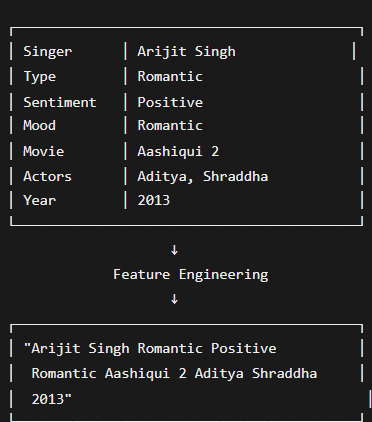

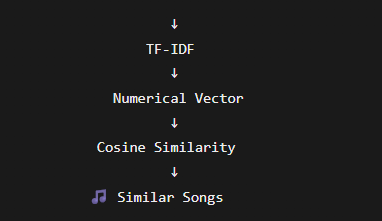

In [4]:
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['search_text'] = df['song_name'].str.lower().str.strip()
df['combined_features'] = (
    df['singer_name'].fillna('') + ' ' +
    df['song_type'].fillna('') + ' ' +
    df['sentiment_label'].fillna('') + ' ' +
    df['mood'].fillna('') + ' ' +
    df['movie_name'].fillna('') + ' ' +
    df['actors'].fillna('') + ' ' +
    df['year'].astype(str)
)
df.head(3)

,song_id,song_name,singer_name,song_type,sentiment_label,mood,year,movie_name,actors,search_text,combined_features
0,HS001,Dil Ne Yeh Kaha Hai Dil Se,"Sonu Nigam, Alka Yagnik",Romantic,Positive,Romantic,2000,Dhadkan,"Akshay Kumar, Shilpa Shetty, Suniel Shetty",dil ne yeh kaha hai dil se,"Sonu Nigam, Alka Yagnik Romantic Positive Romantic Dhadkan Akshay Kumar, Shilpa Shetty, Suniel S..."
1,HS002,Tum Dil Ki Dhadkan Mein,"Kumar Sanu, Alka Yagnik",Romantic,Positive,Romantic,2000,Dhadkan,"Akshay Kumar, Shilpa Shetty, Suniel Shetty",tum dil ki dhadkan mein,"Kumar Sanu, Alka Yagnik Romantic Positive Romantic Dhadkan Akshay Kumar, Shilpa Shetty, Suniel S..."
2,HS003,Apun Bola,Shahrukh Khan,Friendship,Positive,Happy,2000,Josh,"Shah Rukh Khan, Aishwarya Rai, Chandrachur Singh",apun bola,"Shahrukh Khan Friendship Positive Happy Josh Shah Rukh Khan, Aishwarya Rai, Chandrachur Singh 2000"


In [5]:
df['combined_features']

,combined_features
0,"Sonu Nigam, Alka Yagnik Romantic Positive Romantic Dhadkan Akshay Kumar, Shilpa Shetty, Suniel S..."
1,"Kumar Sanu, Alka Yagnik Romantic Positive Romantic Dhadkan Akshay Kumar, Shilpa Shetty, Suniel S..."
2,"Shahrukh Khan Friendship Positive Happy Josh Shah Rukh Khan, Aishwarya Rai, Chandrachur Singh 2000"
3,"Lata Mangeshkar, Udit Narayan Romantic Positive Romantic Mohabbatein Amitabh Bachchan, Shah Rukh..."
4,"Lata Mangeshkar, Udit Narayan, Jaspinder Narula Romantic Positive Happy Mohabbatein Shah Rukh Kh..."
...,...
195,"Master Saleem Romantic Negative Longing Shiddat Sunny Kaushal, Radhika Madan 2021"
196,"Sanjay Leela Bhansali, Janaki Iyer Folk/Dance Positive Energetic Gangubai Kathiawadi Alia Bhatt ..."
197,"Varun Jain, Shadab Faridi, Altamash Faridi, Alif Romantic Positive Romantic Zara Hatke Zara Bach..."
198,"Raghav, Tanishk Bagchi, Asees Kaur Romantic Positive Romantic Teri Baaton Mein Aisa Uljha Jiya S..."


## 2. EDA

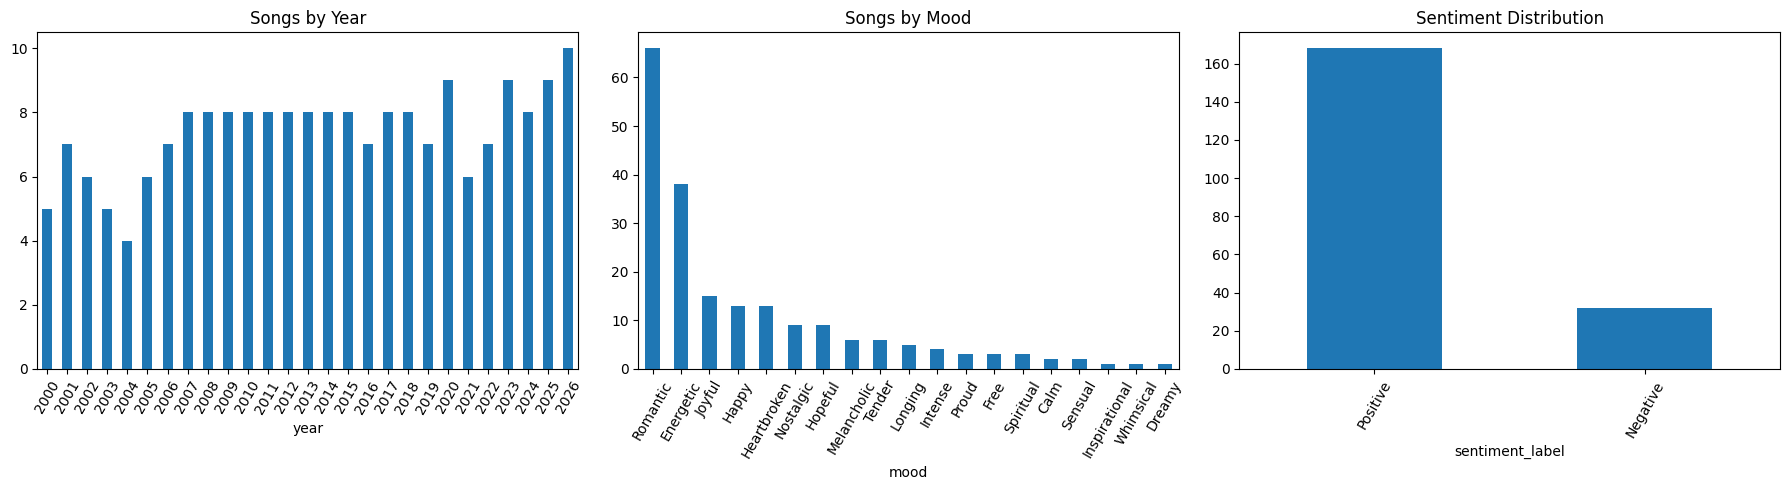

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Songs by Year')
df['mood'].value_counts().plot(kind='bar', ax=axes[1], title='Songs by Mood')
df['sentiment_label'].value_counts().plot(kind='bar', ax=axes[2], title='Sentiment Distribution')
for ax in axes: ax.tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.show()

Ye ek count table banata hai.
##### Matlab:
- Har song type mein kitne Positive, Negative aur Neutral songs hain.
- positive ke basis par sorted hai


In [13]:
pd.crosstab(df['song_type'], df['sentiment_label']).sort_values(by='Positive', ascending=False).head(5)

sentiment_label,Negative,Positive
song_type,,
Romantic,13,88
Party/Dance,0,41
Inspirational,0,11
Friendship,1,5
Rock,0,3


- Yahan hum apne text data ko numbers/vectors mein convert kar rahe hain, taaki machine songs ki similarity calculate kar sake

1. TfidfVectorizer() kya karta hai?
- Computer ke liye ye:
- "Arijit Singh Romantic Positive Love"
- sirf text hai.
- Machine Learning algorithm ko numbers chahiye:
- [0.0, 0.52, 0.0, 0.31, ...]

2. TF-IDF ka simple meaning
- TF-IDF = Term Frequency × Inverse Document Frequency
- Ye basically decide karta hai:
- "Kisi song ke liye kaunsa word important hai?"

Song A:
Arijit Romantic Love

Song B:
Arijit Sad Love

Song C:
Arijit Party Dance

Arijit har jagah aa raha hai → relatively less useful for distinguishing songs.
Romantic sirf Song A mein hai → Song A ko identify karne mein more useful.
So TF-IDF important/unique words ko higher weight deta hai.

3. stop_words='english'
- TfidfVectorizer(stop_words='english')

- Iska matlab common English words ko ignore karo, jaise: the, is, a, an, and, of, to

4. ngram_range=(1, 2)

- iska matlab:
- 1-word aur 2-word combinations dono banao.

## Unigram — 1 word
- Arijit
- Romantic
- Positive
- Love

## Bigram — 2 words
- Arijit Singh
- Shah Rukh
- Rukh Khan

So:
"Arijit Singh Romantic"

becomes roughly:
1-word:
- Arijit
- Singh
- Romantic

2-word:
- Arijit Singh
- Singh Romantic

Isse recommendation system ko word combinations bhi samajhne ka chance milta hai.

5. fit_transform()
- tfidf_matrix = tfidf.fit_transform(df['combined_features'])


#### Ye actually 2 kaam karta hai:
- fit
- Dataset ke saare words ko learn karta hai.
- Example:
- Vocabulary:

  - Arijit
  - Singh
  - Romantic
  - Sad
  - Party
  - Love
  - ...

transform Har song ko numerical vector mein convert karta hai.
- Example conceptually:
- "Arijit Singh Romantic Positive"

        ↓ TF-IDF

[0.42, 0.31, 0.78, 0.15, 0, 0, ...]

### Suppose tumhare paas 200 songs hain
- aur TF-IDF ne 1000 unique features banaye.
Then:
- tfidf_matrix.shape

hoga:
(200, 1000)


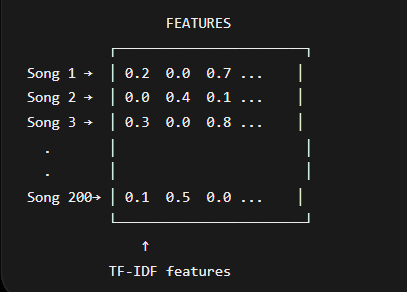

## 3. Feature Engineering with TF-IDF

In [12]:
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['combined_features'])
print('TF-IDF shape:', tfidf_matrix.shape)

TF-IDF shape: (200, 2007)


200 songs ko 2007-dimensional numerical vectors mein represent kiya gaya.

``` text
Song Metadata
     ↓
combined_features
     ↓
"T-Series Romantic Positive Love ..."
     ↓
TF-IDF Vectorizer
     ↓
Numerical Vectors
     ↓
Cosine Similarity
     ↓
Similar Songs
```

## TF-IDF text ko numerical representation mein convert karta hai, jisse ML model words/features ke basis par songs ko compare kar sakta hai.

## 4. Similarity Matrix

Har song ko har doosre song ke saath compare karna hai.

Suppose:
similarity_matrix[0][1] = 0.82

Matlab:
Song 0 aur Song 1 ki similarity 0.82 hai.

``` text
0   → very different
      ↓
0.5 → somewhat similar
      ↓
1   → highly similar

```

In [15]:
similarity_matrix = cosine_similarity(tfidf_matrix)
print('Similarity matrix:', similarity_matrix.shape)
print(similarity_matrix)

Similarity matrix: (200, 200)
[[1.         0.85970464 0.04002457 ... 0.02445749 0.02728383 0.03577503]
 [0.85970464 1.         0.03827017 ... 0.02338544 0.02608789 0.0342069 ]
 [0.04002457 0.03827017 1.         ... 0.01302953 0.00206213 0.00270389]
 ...
 [0.02445749 0.02338544 0.01302953 ... 1.         0.01988757 0.02607693]
 [0.02728383 0.02608789 0.00206213 ... 0.01988757 1.         0.02909041]
 [0.03577503 0.0342069  0.00270389 ... 0.02607693 0.02909041 1.        ]]


## 5. Basic Content-Based Recommender

- find_song_index() → user ne jo song diya, uska row/index dhoondo
- recommend_basic() → us song ke most similar songs dhoondo

matches = df.index[
    df['song_name'].str.casefold().eq(song_name.casefold())
].tolist()

### Step 1: Song names nikalo
- df['song_name']

```text
Example:
0    Tum Hi Ho
1    Agar Tum Saath Ho
2    Channa Mereya
3    Kesariya
...
```
### Step 2: casefold()
df['song_name'].str.casefold()


- sabko lowercase-like comparison form mein convert karta hai:
``` text
Tum Hi Ho
tum hi ho

Channa Mereya
channa mereya
```

Step 3: .eq()
df['song_name'].str.casefold().eq(song_name.casefold())

``` text
Agar user ne:
Tum Hi Ho

diya, toh comparison kuch aisa hoga:
Tum Hi Ho          → True
Agar Tum Saath Ho  → False
Channa Mereya      → False
Kesariya           → False
```

## Step 4: df.index[...]
Ab jahan True hai, uska index chahiye.
``` text
0 → True
1 → False
2 → False
3 → False
```
Step 5: .tolist()
Pandas result ko normal Python list bana deta hai:

In [19]:
def find_song_index(song_name):
    matches = df.index[df['song_name'].str.casefold().eq(song_name.casefold())].tolist()
    if not matches:
        raise ValueError(f'Song not found: {song_name}')
    return matches[0]

def recommend_basic(song_name, n=5):
    idx = find_song_index(song_name)
    print(f"{song_name} found in {idx}th index")
    scores = np.argsort(similarity_matrix[idx])[::-1]
    scores = [i for i in scores if i != idx][:n]
    out = df.loc[scores, ['song_name','singer_name','song_type','mood','sentiment_label','year','movie_name']].copy()
    out['similarity'] = [similarity_matrix[idx, i] for i in scores]
    return out.reset_index(drop=True)

recommend_basic('Tum Hi Ho', 8)

Tum Hi Ho found in 70th index


,song_name,singer_name,song_type,mood,sentiment_label,year,movie_name,similarity
0,Chahun Main Ya Naa,"Arijit Singh, Palak Muchhal",Romantic,Romantic,Positive,2013,Aashiqui 2,0.823286
1,Chal Ghar Chalen,Arijit Singh,Romantic,Romantic,Positive,2020,Malang,0.399871
2,Zamaana Lage,"Arijit Singh, Shashaa Tirupati",Romantic,Romantic,Positive,2025,Metro... In Dino,0.306761
3,Humraah,Sachet Tandon,Romantic,Romantic,Positive,2020,Malang,0.282779
4,Aaj Bhi,Papon,Romantic,Nostalgic,Negative,2025,Metro... In Dino,0.238070
5,Humdard,Arijit Singh,Romantic,Tender,Positive,2014,Ek Villain,0.223171
6,Kesariya,Arijit Singh,Romantic,Romantic,Positive,2022,Brahmastra,0.192853
7,Tujhe Kitna Chahne Lage,Arijit Singh,Romantic,Romantic,Positive,2019,Kabir Singh,0.192112


def recommend_basic(song_name, n=5):
n=5 matlab uske similar 5 songs
Tum Hi Ho → index 70

## 5. Similarity scores nikalo
scores = np.argsort(similarity_matrix[idx])[::-1]


``` text
Ye sabse important line hai.
Suppose Tum Hi Ho ki similarity row:
Index:       0     1     2     3     4
Similarity: .42   .91   .35   1.00  .76
```

np.argsort() indices ko small → large order mein sort karega.
[2, 0, 4, 1, 3]

[::-1] usko reverse karta hai:
[3, 1, 4, 0, 2]

``` text
Ab:
highest similarity
       ↓
Index 3 → 1.00
Index 1 → 0.91
Index 4 → 0.76
Index 0 → 0.42
Index 2 → 0.35
```

### Khud ko recommendation mein mat do 😄
scores = [i for i in scores if i != idx][:n]


Problem:
Tum Hi Ho
   ↓
Tum Hi Ho = similarity 1.0

Agar hum isko remove nahi karenge toh recommendation mein:
1. Tum Hi Ho       1.00
2. Song A          0.91
3. Song B          0.86

aa jayega.
Humein khud song nahi chahiye.
Isliye:
if i != idx


Matlab:
current song ko hata do.

Then:
[:n]


sirf first n songs leta hai.



```text
Recommended songs ka data nikalo
out = df.loc[    scores,    ['song_name',     'singer_name',     'song_type',     'mood',     'sentiment_label',     'year',     'movie_name']].copy()
```

df.loc[scores] ka matlab:
Jo indices scores mein hain, un rows ko DataFrame se nikalo.

Aur sirf ye columns chahiye:
- Song name
- Singer
- Song type
- Mood
- Sentiment
- Year
- Movie

Similarity score bhi add karo
out['similarity'] = [    similarity_matrix[idx, i]    for i in scores]


```text
Suppose recommendations:
Song A → 0.91
Song B → 0.87
Song C → 0.82
```

```text
Toh output mein ek extra column banega:
song_name	singer	similarity
Song A	Singer A	0.91
Song B	Singer B	0.87
Song C	Singer C	0.82
```

Yaani user ko ye bhi dikha sakte ho ki recommendation kitni similar hai.


### reset_index(drop=True)
- return out.reset_index(drop=True)
``` text
Suppose original indices the:
37
81
12
156
44

Output mein hum usually:
0
1
2
3
4
```
chahte hain.
drop=True purana index hata deta hai.

## 6. Mood + Sentiment Aware Recommender

In [ ]:
def recommend(song_name, mood=None, sentiment=None, n=10):
    idx = find_song_index(song_name)
    content = similarity_matrix[idx].copy()
    years = df['year'].to_numpy(dtype=float)
    year_similarity = 1 - np.abs(years - years[idx]) / max(1, years.max() - years.min())
    mood_match = df['mood'].eq(mood).astype(float).to_numpy() if mood else np.zeros(len(df))
    sentiment_match = df['sentiment_label'].eq(sentiment).astype(float).to_numpy() if sentiment else np.zeros(len(df))

    if mood and sentiment:
        score = 0.70*content + 0.15*mood_match + 0.10*sentiment_match + 0.05*year_similarity
    elif mood:
        score = 0.80*content + 0.15*mood_match + 0.05*year_similarity
    elif sentiment:
        score = 0.80*content + 0.15*sentiment_match + 0.05*year_similarity
    else:
        score = content

    score[idx] = -1
    top = np.argsort(score)[::-1][:n]
    out = df.loc[top, ['song_name','singer_name','song_type','mood','sentiment_label','year','movie_name']].copy()
    out['recommendation_score'] = score[top]
    return out.reset_index(drop=True)

recommend('Kesariya', mood='Romantic', sentiment='Positive', n=10)

### Why this works
- **TF-IDF:** represents metadata as weighted numerical features.
- **Cosine similarity:** finds songs whose feature vectors point in similar directions.
- **Mood/sentiment re-ranking:** adds an explicit user-context layer.


- Recommendation: "Is song ke similar songs kaunse hain?"
- Clustering: "Mere 200 songs naturally kin groups mein divide hote hain?"

## 7. K-Means Song Clustering

- TF-IDF matrix ko normal NumPy array banana
``` text
Pehle:
tfidf_matrix
     ↓
Sparse Matrix

toarray() usko normal dense NumPy array mein convert karta hai:
X
↓
[ [0.2, 0, 0.5, ...],
  [0, 0.4, 0.1, ...],
  [0.3, 0, 0, ...] ]

Agar 200 songs aur 850 features hain:
X.shape


will be approximately:
(200, 850)

So:
200 rows → 200 songs
850 columns → TF-IDF features
```

KMeans clustering
kmeans = KMeans(    n_clusters=8,    random_state=42,    n_init=10)


Yahan hum bol rahe hain:
"Mere songs ko 8 groups mein divide karo."

```text
For example, clusters could roughly represent:
Cluster 0 → Romantic songs
Cluster 1 → Party songs
Cluster 2 → Sad songs
Cluster 3 → Devotional
...
```

But important: KMeans ko ye labels pata nahi hain. Ye automatically feature similarity ke basis par groups banata hai.
``` text

Ab groupby('cluster')
df.groupby('cluster')


Matlab:
Cluster number ke according songs ko groups mein divide karo.

Example:
Cluster 0
 ├── Song A
 ├── Song B
 └── Song C

Cluster 1
 ├── Song D
 ├── Song E
 └── Song F

common_mood
common_mood=('mood', lambda x: x.mode().iat[0])

Cluster ke moods dekho:
Happy
Happy
Romantic
Happy
Sad

mode():
Happy

Matlab most frequent mood.
.iat[0] first mode ko select karta hai.

common_type
Same logic:
common_type=('song_type', lambda x: x.mode().iat[0])

Suppose:
Party
Romantic
Party
Party
Sad

Result:
Party

Finally sorting
.sort_values('songs', ascending=False)


Clusters ko number of songs ke basis par largest → smallest sort karega.


Output kuch aisa ho sakta hai:
cluster	songs	common_mood	common_type
3	       42	    Happy     	Party
1        35     Romantic	  Love
6        31     Sad	        Emotional
0        27     Energetic	  Dance

 ```

In [24]:
X = tfidf_matrix.toarray()
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.groupby('cluster').agg(
    songs=('song_name','count'),
    common_mood=('mood', lambda x: x.mode().iat[0]),
    common_type=('song_type', lambda x: x.mode().iat[0])
).sort_values('songs', ascending=False)

,songs,common_mood,common_type
cluster,,,
2,187,Romantic,Romantic
0,3,Energetic,Party/Dance
4,3,Energetic,Romantic
1,2,Calm,Friendship
7,2,Happy,Inspirational
3,1,Romantic,Romantic
5,1,Energetic,Party/Dance
6,1,Calm,Romantic


## 8. Preference-Based Recommendations

- user ki preference ke basis par songs recommend karta hai. Isme hum similarity matrix use nahi kar rahe; instead custom scoring system

iska simple meaning:
Energetic mood + Positive sentiment wale top 10 songs do.

Yahan 3 inputs hain:
- mood      → user ka desired mood
- sentiment → desired sentiment
- n         → kitne songs chahiye

``` text
Original df ko directly modify nahi karna.
Hum ek temporary copy banate hain:
df
 ↓
copy()
 ↓
candidates

Ab hum candidates mein score column add kar sakte hain.
```
- Sabse important:
- score
candidates['score'] = (    0.70*candidates['mood'].eq(mood).astype(float) +    0.20 * candidates['sentiment_label'].eq(sentiment).astype(float) +    0.10 * ((candidates['year']-df['year'].min())/(df['year'].max()-df['year'].min())))


```text
Ye basically ek scoring formula hai.
Hum decide kar rahe hain:
Mood match       → 70%
Sentiment match  → 20%
Year              → 10%
```

```text
Sentiment matching
candidates['sentiment_label'].eq(sentiment).astype(float)


Suppose:
sentiment = Positive

Then:
Positive → 1
Negative → 0
Neutral  → 0

And:
0.20 * ...


So:
Positive → 0.20
Others   → 0
```
Year wala part
((candidates['year'] - df['year'].min()) / (df['year'].max() - df['year'].min()))


```text
Ye year ko 0–1 range mein normalize kar raha hai.
Suppose dataset mein:
min year = 2000
max year = 2026

Agar song 2000 ka hai:
(2000 - 2000) / 26 = 0

Agar song 2026 ka hai:
(2026 - 2000) / 26 = 1

2013 approximately:
(2013 - 2000) / 26 ≈ 0.50

Then:
0.10 * normalized_year

matlab year ko 10% weight diya.
```

```text
Ek actual example
Suppose:
Song A
Mood       = Energetic
Sentiment  = Positive
Year       = 2026

Score:
Mood       = 0.70
Sentiment  = 0.20
Year       = 0.10 × 1 = 0.10
────────────────────────────
Total      = 1.00

Song
Mood       = Energetic
Sentiment  = Negative
Year       = 2020

Suppose normalized year ≈ 0.77:
Mood       = 0.70
Sentiment  = 0
Year       = 0.10 × 0.77 = 0.077
────────────────────────────
Total      ≈ 0.777

Song C
Mood       = Sad
Sentiment  = Positive
Year       = 2026

Mood       = 0
Sentiment  = 0.20
Year       = 0.10
────────────────
Total      = 0.30

Therefore:
Song A → 1.00
Song B → 0.777
Song C → 0.30
```


In [25]:
def recommend_by_preferences(mood, sentiment='Positive', n=10):
    candidates = df.copy()
    candidates['score'] = (
        0.70*candidates['mood'].eq(mood).astype(float) +
        0.20*candidates['sentiment_label'].eq(sentiment).astype(float) +
        0.10*((candidates['year']-df['year'].min())/(df['year'].max()-df['year'].min()))
    )
    return candidates.sort_values('score', ascending=False).head(n)[
        ['song_name','singer_name','mood','sentiment_label','year','movie_name','score']
    ]

recommend_by_preferences('Energetic', 'Positive', 10)

,song_name,singer_name,mood,sentiment_label,year,movie_name,score
154,Shararat,"Shashwat Sachdev, Madhubanti Bagchi, Jasmine Sandlas",Energetic,Positive,2026,Dhurandhar: The Revenge,1.0
155,Mashooqa,"Pritam, Mahmood, Raghav Chaitanya, Ruaa Kayy",Energetic,Positive,2026,Cocktail 2,1.0
150,Laal Pari,"Yo Yo Honey Singh, Simar Kaur, Sukhwinder Singh",Energetic,Positive,2025,Housefull 5,0.996154
142,Naina,"Diljit Dosanjh, Badshah",Energetic,Positive,2024,Crew,0.992308
138,Ishq Jaisa Kuch,"Vishal Dadlani, Shekhar Ravjiani, Shilpa Rao, Mellow D",Energetic,Positive,2024,Fighter,0.992308
140,Aaj Ki Raat,"Madhubanti Bagchi, Divya Kumar, Sachin-Jigar",Energetic,Positive,2024,Stree 2,0.992308
139,Achacho,Kharesma Ravichandran,Energetic,Positive,2024,Aranmanai 4,0.992308
137,Heer Aasmani,"Vishal Dadlani, Shekhar Ravjiani, B Praak",Energetic,Positive,2024,Fighter,0.992308
129,Tere Pyaar Mein,"Pritam, Arijit Singh, Nikhita Gandhi",Energetic,Positive,2023,Tu Jhoothi Main Makkaar,0.988462
134,Not Ramaiya Vastavaiya,"Anirudh Ravichander, Vishal Dadlani, Shilpa Rao",Energetic,Positive,2023,Jawan,0.988462


year ko 10% dene ka matlab newer songs ko automatically advantage mil raha hai. Agar tum nahi chahte ki latest song ko sirf year ki wajah se preference mile, toh year component hata sakte ho ya user ko preferred year/range dene ka option de sakte ho.

## 9. Save Model Artifacts

In [ ]:
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(similarity_matrix, 'similarity_matrix.joblib')
joblib.dump(kmeans, 'kmeans_song_model.joblib')
df.to_csv('hindi_songs_with_clusters.csv', index=False)
print('Artifacts saved successfully.')

## 10. Next-Level AI Upgrades 🚀

1. Add **lyrics embeddings** with a sentence-transformer model.
2. Add licensed **audio features** such as energy, danceability, tempo and valence.
3. Build a hybrid recommender: `content similarity + collaborative filtering`.
4. Add user profiles and session history.
5. Expose the model with **FastAPI**.
6. Build a **React/Streamlit** interface.
7. Evaluate using Precision@K, Recall@K and human relevance tests.
